<a href="https://colab.research.google.com/github/Ab-126/Machine_Learning/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/DataSets/placement.csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [ ]:
df.shape

(200, 2)

Text(0, 0.5, 'Package (in LPA)')

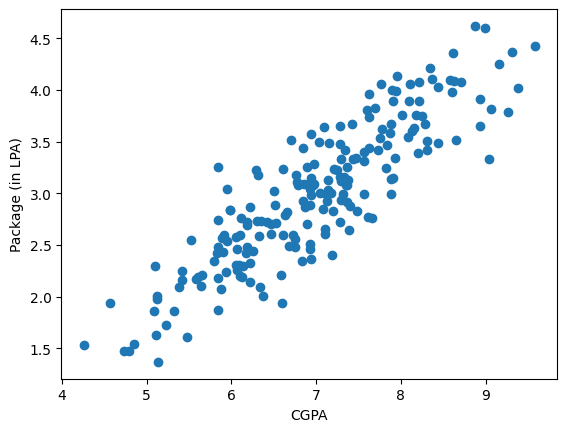

In [ ]:
plt.scatter(x=df['cgpa'], y=df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package (in LPA)')

In [ ]:
X = df.iloc[:, 0:1]
y = df.iloc[:, -1]

In [ ]:
y

,package
0,3.26
1,1.98
2,3.25
3,3.67
4,3.57
...,...
195,2.46
196,2.57
197,3.24
198,3.96


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

Text(0, 0.5, 'Package (in LPA)')

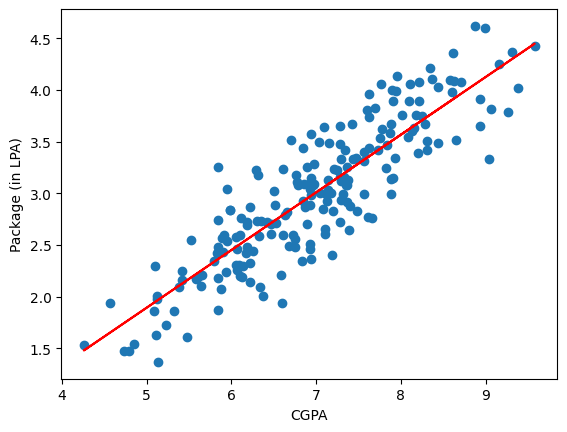

In [ ]:
plt.scatter(x=df['cgpa'], y=df['package'])
plt.plot(X_train, lr.predict(X_train), color='red')
plt.xlabel("CGPA")
plt.ylabel("Package (in LPA)")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [ ]:
print("MAE", mean_absolute_error(y_test, y_pred))
print("MSE", mean_squared_error(y_test, y_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE 0.2884710931878175
MSE 0.12129235313495527
RMSE 0.34827051717731616


In [ ]:
r2 = r2_score(y_test, y_pred)
print("r2_score", r2)

r2_score 0.780730147510384


In [ ]:
X_test.shape

(40, 1)

In [ ]:
# Adjusted R2 Score
1 - ((1-r2)*(40-1)/(40-1-1))

0.7749598882343415

In [ ]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[["cgpa", "random_feature", "package"]]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.940658,3.26
1,5.12,0.913350,1.98
2,7.82,0.068935,3.25
3,7.42,0.802024,3.67
4,6.94,0.793364,3.57


Text(0, 0.5, 'package (in lpa)')

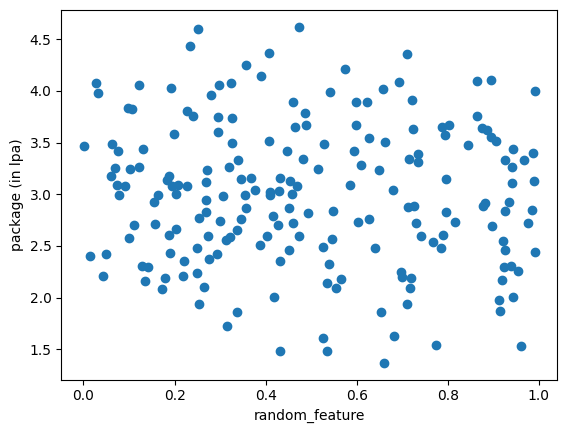

In [ ]:
plt.scatter(x=new_df1['random_feature'], y=new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('package (in lpa)')

In [ ]:
X = new_df1.iloc[:, 0: 2]
y = new_df1.iloc[:, -1]

In [ ]:
y

,package
0,3.26
1,1.98
2,3.25
3,3.67
4,3.57
...,...
195,2.46
196,2.57
197,3.24
198,3.96


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.7820679243277977


In [ ]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.7702878121293003

In [ ]:
m = lr.coef_
b = lr.intercept_
print("m is ", m, " and b is ", b)

m is  [0.55942274 0.03624698]  and b is  -0.9243417793101476


## Own simple linear regression

In [ ]:
class MeraLR:

    def __init__(self):
        self.m = None
        self.b = None

    def fit(self,X_train,y_train):

        num = 0
        den = 0

        for i in range(X_train.shape[0]):

            num = num + ((X_train[i] - X_train.mean())*(y_train[i] - y_train.mean()))
            den = den + ((X_train[i] - X_train.mean())*(X_train[i] - X_train.mean()))

        self.m = num/den
        self.b = y_train.mean() - (self.m * X_train.mean())
        print(self.m)
        print(self.b)

    def predict(self,X_test):

        print(X_test)

        return self.m * X_test + self.b

# Multiple Linear Regression

In [ ]:
import numpy as np
from sklearn.datasets import load_diabetes

In [ ]:
X, y = load_diabetes(return_X_y=True)

In [ ]:
X.shape

(442,)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_test.shape)

(353, 10)
(89, 10)
(89,)


In [ ]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = reg.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.4399338661568968

In [ ]:
print("coefficient", reg.coef_)
print("intercept", reg.intercept_)

coefficient [  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
intercept 151.88331005254167


## Making your own muliple linear regression

In [ ]:
class MeraLR:

    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self,X_train,y_train):
        X_train = np.insert(X_train,0,1,axis=1)

        # calcuate the coeffs
        betas = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
        self.intercept_ = betas[0]
        self.coef_ = betas[1:]

    def predict(self,X_test):
        y_pred = np.dot(X_test,self.coef_) + self.intercept_
        return y_pred



In [ ]:
lr = MeraLR()
lr.fit(X_train,y_train)
print("Before", X_train.shape)
np.insert(X_train,0,1,axis=1).shape

Before (353, 10)


(353, 11)

In [ ]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.43993386615689634

In [ ]:
lr.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [ ]:
lr.intercept_